In [1]:
import numpy as np
print(np.__version__)

1.23.5


### Q.1 ###

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200))
])

# Train model
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### Q.2 ###

In [5]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 0.7447522931803241
MAE: 0.5471906209387924
R2 Score: 0.5916156274684824


In [17]:
import os
print(os.getcwd())

C:\Users\hp


### Q.3 ###

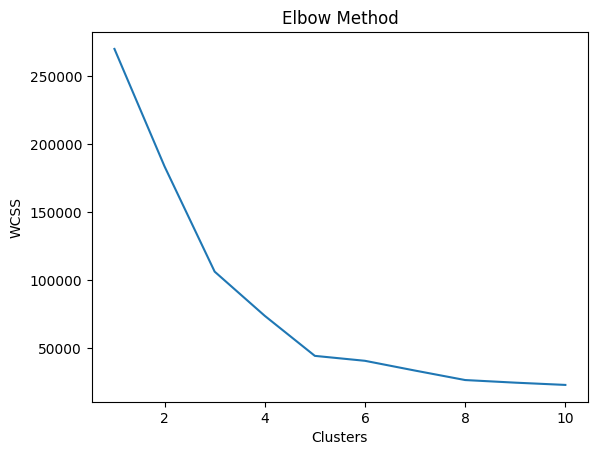

Silhouette Score: 0.553931997444648


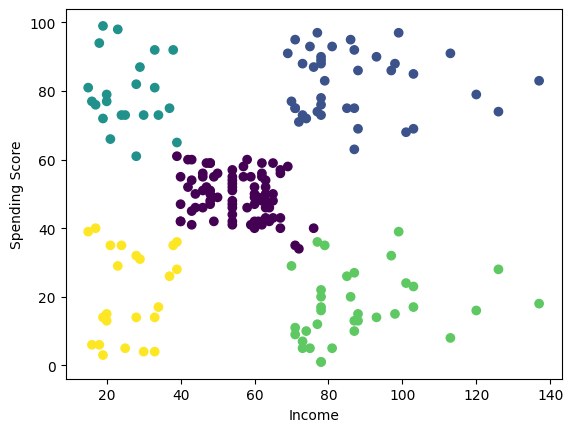

In [15]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


df = pd.read_csv(r"C:\Users\hp\Mall_Customers.csv")

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

# KMeans with optimal clusters 
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Silhouette Score
print("Silhouette Score:", silhouette_score(X, y_kmeans))

# Visualization
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_kmeans)
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

### Q.4 ###

In [21]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.92461872 0.05306648]


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy after PCA:", accuracy_score(y_test, y_pred))

Accuracy after PCA: 1.0


### Q.5(a) ###

In [29]:
z = (76 - 60) / 8
print("Z-score:", z)

Z-score: 2.0


### Q.5(b) ###

In [31]:
from sklearn.linear_model import LinearRegression

X = np.array([1,2,3,4]).reshape(-1,1)
y = np.array([2,4,5,4])

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

# Prediction for x=5
print("Prediction for x=5:", model.predict([[5]]))

Slope: 0.6999999999999997
Intercept: 2.000000000000001
Prediction for x=5: [5.5]


### Q.5(c) ###

In [33]:
from sklearn.metrics import mean_squared_error

actual = [10, 12, 14]
pred = [11, 11, 15]

print("MSE:", mean_squared_error(actual, pred))

MSE: 1.0


### Q.5(d) ###

In [35]:
import math

def entropy(p):
    return -p*math.log2(p) if p != 0 else 0

# Example probabilities
p_yes = 3/5
p_no = 2/5

entropy_total = entropy(p_yes) + entropy(p_no)
print("Entropy:", entropy_total)

Entropy: 0.9709505944546686


### Q.5(e) ###

In [37]:
predictions = ["Yes","No","Yes","Yes","No","Yes","Yes"]

from collections import Counter
print("Final Output:", Counter(predictions).most_common(1))

Final Output: [('Yes', 5)]


### Q.5(f) ###

In [39]:
P_spam = 0.4
P_word_spam = 0.7
P_word_notspam = 0.2

P_notspam = 1 - P_spam

P_word = (P_word_spam * P_spam) + (P_word_notspam * P_notspam)

P_spam_given_word = (P_word_spam * P_spam) / P_word

print("P(Spam | Word):", P_spam_given_word)

P(Spam | Word): 0.7
